Feature sensitivity analysis

This code evaluates how sensitive selected acoustic features are to different perturbation groups (intensity, Gaussian noise, pink noise, and low-pass filtering).

Steps:
1. Load feature files for the original audio and all perturbation levels.
2. Sort all files by participant ID and filename to ensure row-wise alignment.
3. Check that each perturbed file matches the corresponding original file.
4. Select the acoustic features of interest.
5. For each feature and perturbation group:
   - combine the feature values from the original and all perturbation levels
   - standardize the feature values within that perturbation group
6. Compute the absolute difference between the standardized original and standardized perturbed feature values.
7. Average these differences over all the audio files per perturbation level 
8. Average the levels of perturbations over each other, to create one value for each perturbation



In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler

#1. Load files and set output path 
BASE_PATH = Path(r"C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht")

OUTPUT_FILE = BASE_PATH / "feature_sensitivity_table_standardized_features_per_group.csv"

# 2. selected features 
selected_features = {
    "F0 Mean": "F0semitoneFrom27.5Hz_sma3nz_amean",
    "F0 20th%": "F0semitoneFrom27.5Hz_sma3nz_percentile20.0",
    "F0 50th%": "F0semitoneFrom27.5Hz_sma3nz_percentile50.0",
    "F0 80th%": "F0semitoneFrom27.5Hz_sma3nz_percentile80.0",
    "F0 StdDev": "F0semitoneFrom27.5Hz_sma3nz_stddevNorm",
    "F1 Mean": "F1frequency_sma3nz_amean",
    "F1 StdDev": "F1frequency_sma3nz_stddevNorm",
    "F2 Mean": "F2frequency_sma3nz_amean",
    "F2 StdDev": "F2frequency_sma3nz_stddevNorm",
    "F3 Mean": "F3frequency_sma3nz_amean",
    "F3 StdDev": "F3frequency_sma3nz_stddevNorm",
    "HNR Mean": "HNRdBACF_sma3nz_amean",
    "HNR StdDev": "HNRdBACF_sma3nz_stddevNorm",
    "Jitter Mean": "jitterLocal_sma3nz_amean",
    "Amplitude Mean": "loudness_sma3_amean",
    "Amplitude 20th%": "loudness_sma3_percentile20.0",
    "Amplitude 50th%": "loudness_sma3_percentile50.0",
    "Amplitude 80th%": "loudness_sma3_percentile80.0",
    "Amplitude StdDev": "loudness_sma3_stddevNorm",
    "MFCC1 Mean": "mfcc1_sma3_amean",
    "MFCC1 StdDev": "mfcc1_sma3_stddevNorm",
    "MFCC2 Mean": "mfcc2_sma3_amean",
    "MFCC2 StdDev": "mfcc2_sma3_stddevNorm",
    "MFCC3 Mean": "mfcc3_sma3_amean",
    "MFCC3 StdDev": "mfcc3_sma3_stddevNorm",
    "MFCC4 Mean": "mfcc4_sma3_amean",
    "MFCC4 StdDev": "mfcc4_sma3_stddevNorm",
    "Shimmer Mean": "shimmerLocaldB_sma3nz_amean",
}

# 3. Define perturbation groups and corresponding files
perturbation_groups = {
    "Intensity": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "-6": BASE_PATH / "opensmile_intensity_-6dB_features_pain.csv",
        "-3": BASE_PATH / "opensmile_intensity_-3dB_features_pain.csv",
        "+3": BASE_PATH / "opensmile_intensity_3dB_features_pain.csv",
        "+6": BASE_PATH / "opensmile_intensity_6dB_features_pain.csv",
    },
    "Gaussian noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_gaussian_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_gaussian_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_gaussian_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_gaussian_features_pain.csv",
    },
    "Pink noise": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "0.5": BASE_PATH / "opensmile_low_pink_features_pain.csv",
        "2": BASE_PATH / "opensmile_medium_pink_features_pain.csv",
        "5": BASE_PATH / "opensmile_high_pink_features_pain.csv",
        "10": BASE_PATH / "opensmile_very_high_pink_features_pain.csv",
    },
    "Low-pass filter": {
        "original": BASE_PATH / "opensmile_wiener_features_pain.csv",
        "6000": BASE_PATH / "opensmile_low_lowpass_features_pain.csv",
        "5000": BASE_PATH / "opensmile_medium_lowpass_features_pain.csv",
        "4000": BASE_PATH / "opensmile_high_lowpass_features_pain.csv",
        "3000": BASE_PATH / "opensmile_very_high_lowpass_features_pain.csv",
    },
}

# helper functions
def load_and_sort_csv(file_path):
    """Load CSV and sort rows so all files align across conditions."""
    df = pd.read_csv(file_path)
    df = df.sort_values(by=["participant_id", "filename"]).reset_index(drop=True)
    return df


def check_alignment(reference_df, comparison_df, label):
    """Check whether rows correspond to the same participant/file pairs."""
    ref_ids = reference_df[["participant_id", "filename"]]
    cmp_ids = comparison_df[["participant_id", "filename"]]

    if not ref_ids.equals(cmp_ids):
        raise ValueError(f"Mismatch in rows for {label}")


# load data 
all_data = {}

for group_name, files in perturbation_groups.items():
    all_data[group_name] = {}
    for level_label, file_path in files.items():
        all_data[group_name][level_label] = load_and_sort_csv(file_path)

# check alignment and features 
for group_name, dfs in all_data.items():
    original_df = dfs["original"]

    for level_label, df in dfs.items():
        if level_label == "original":
            continue
        check_alignment(original_df, df, f"{group_name} - {level_label}")

reference_original = all_data["Intensity"]["original"]

missing_features = [
    feature_col
    for feature_col in selected_features.values()
    if feature_col not in reference_original.columns
]

if missing_features:
    raise ValueError(f"These features are missing from the CSV files: {missing_features}")

# dataframe to store results
results = pd.DataFrame(
    index=selected_features.keys(),
    columns=perturbation_groups.keys(),
    dtype=float
)

# 5. Calculate sensitivity scores
for feature_name, feature_col in selected_features.items():

    for group_name, dfs in all_data.items():

        # Collect all values of this feature within
        # this perturbation group:
        # original + all perturbation level 
        combined_values = []

        for level_label, df in dfs.items():
            combined_values.extend(df[feature_col].to_numpy())

        combined_values = np.array(combined_values).reshape(-1, 1)

        # Fit scaler on this feature within this group
        scaler = StandardScaler()
        scaler.fit(combined_values)

        # Standardize original feature values
        original_std = scaler.transform(
            dfs["original"][[feature_col]].to_numpy()
        ).flatten()

        # Store mean absolute difference per level
        level_scores = []

        for level_label, df in dfs.items():
            if level_label == "original":
                continue

            # Standardize perturbed feature values
            perturbed_std = scaler.transform(
                df[[feature_col]].to_numpy()
            ).flatten()

            # Difference between standardized original and perturbation
            abs_diff = np.abs(original_std - perturbed_std)

            # Mean absolute difference for this level
            mean_abs_diff = abs_diff.mean()
            level_scores.append(mean_abs_diff)

        # Average across all levels within this perturbation group
        results.loc[feature_name, group_name] = np.mean(level_scores)

# print results 
results.to_csv(OUTPUT_FILE)

print("Feature sensitivity table saved to:")
print(OUTPUT_FILE)
print()
print(results)

Feature sensitivity table saved to:
C:\Users\marti\Documents\Technical Medicine Master\Stages TM2\TM2-3\Technische opdracht\feature_sensitivity_table_standardized_features_per_group.csv

                  Intensity  Gaussian noise  Pink noise  Low-pass filter
F0 Mean            0.004661        0.186504    0.132597         0.009288
F0 20th%           0.004813        0.268114    0.185050         0.011615
F0 50th%           0.005067        0.089266    0.063559         0.011921
F0 80th%           0.001380        0.039117    0.028155         0.003187
F0 StdDev          0.010704        0.475889    0.320568         0.018707
F1 Mean            0.040817        0.333534    0.271597         0.098608
F1 StdDev          0.052338        0.364904    0.329930         0.125080
F2 Mean            0.040366        0.304443    0.267983         0.099621
F2 StdDev          0.061017        0.441285    0.381057         0.148698
F3 Mean            0.038634        0.447937    0.338173         0.108237
F3 StdDev 

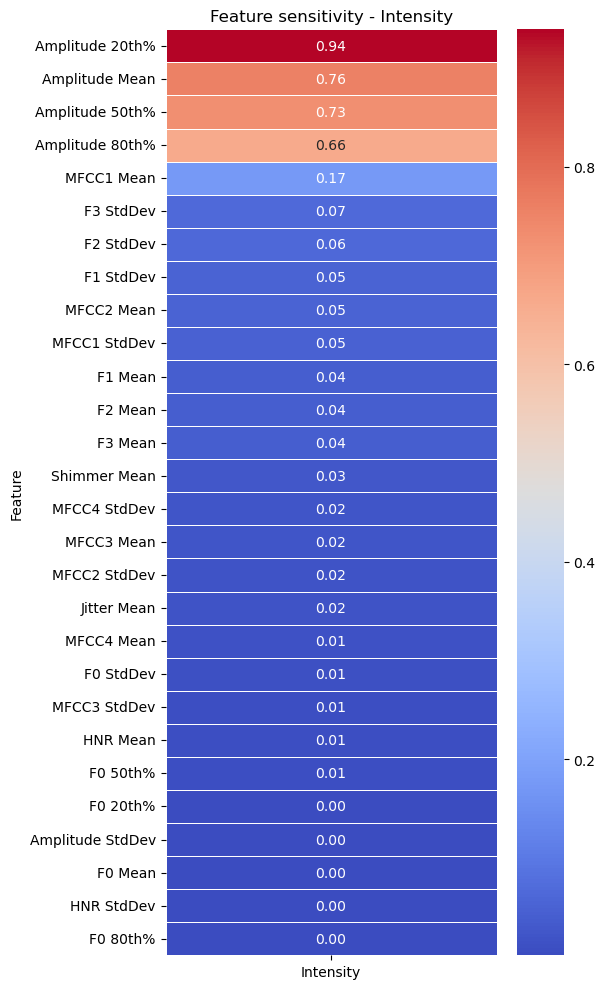

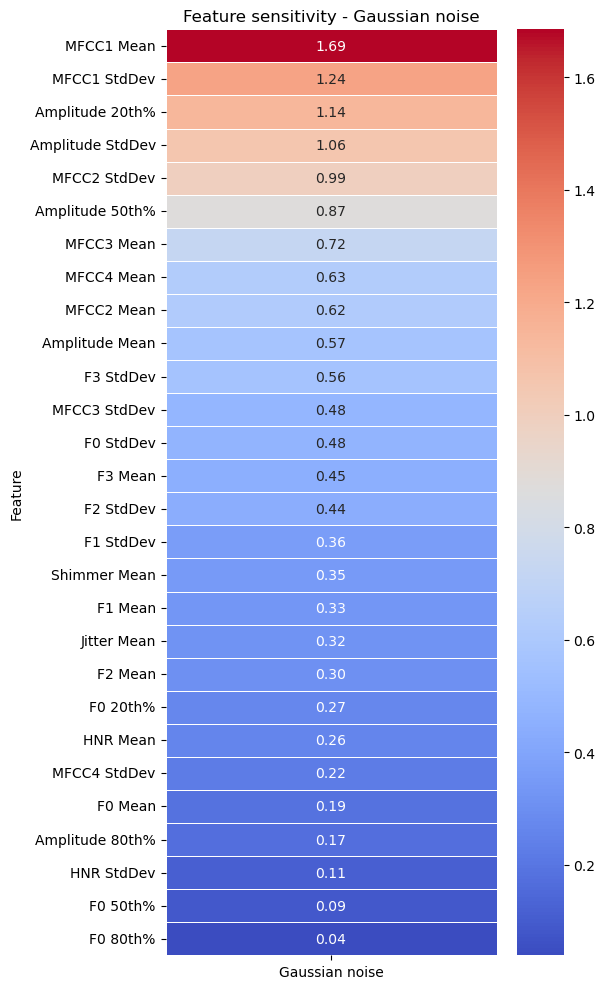

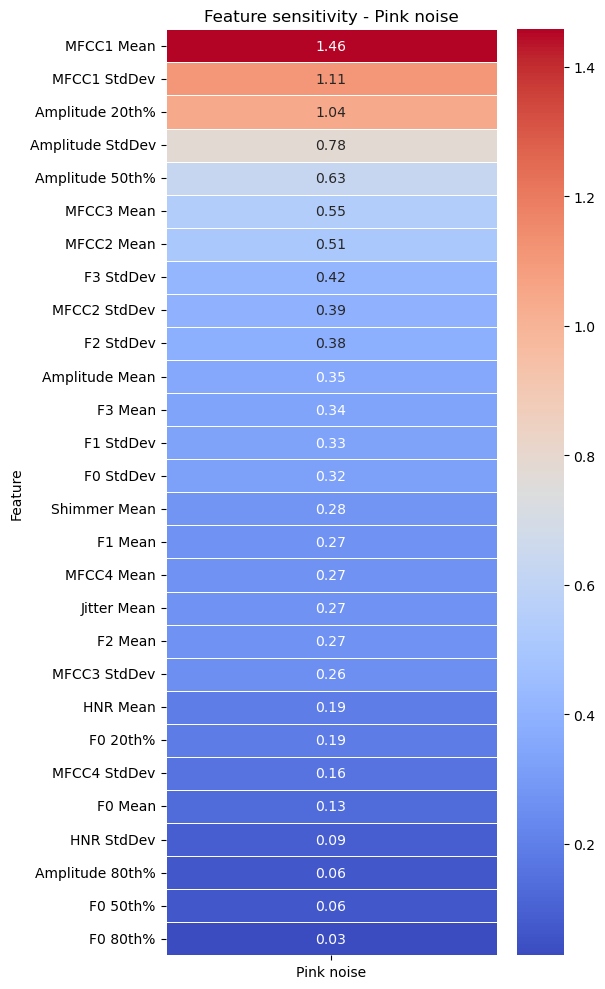

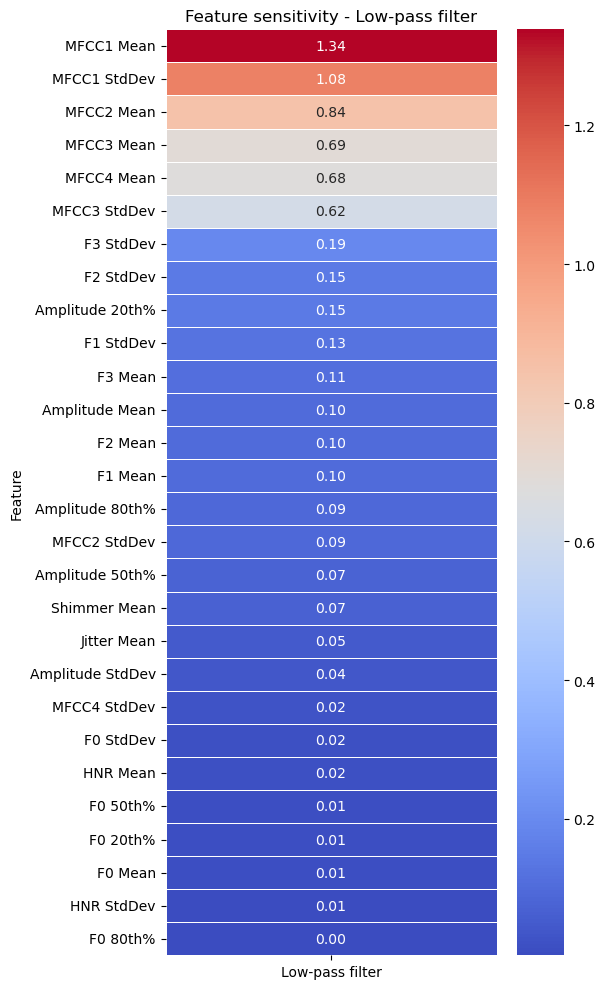

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

HEATMAP_DIR = BASE_PATH / "heatmaps_per_perturbation"
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)

for group_name in results.columns:

    heatmap_data = results[[group_name]].copy()
    heatmap_data = heatmap_data.sort_values(by=group_name, ascending=False)

    plt.figure(figsize=(6, 10))

    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",   # rood-blauw
        linewidths=0.5,
        cbar=True
    )

    plt.title(f"Feature sensitivity - {group_name}")
    plt.xlabel("")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.savefig(HEATMAP_DIR / f"heatmap_{group_name.replace(' ', '_')}.png", dpi=300)
    plt.show()
    plt.close()